# t-SNE e métodos de manifold

**Tema:** Aprendizado Não Supervisionado › Redução de Dimensionalidade

Este notebook calcula as afinidades do t-SNE à mão (e a busca binária que
acha $\sigma_i$ pela perplexidade), compara PCA e t-SNE com uma métrica
objetiva de preservação de vizinhança, reproduz as armadilhas de
interpretação do `teoria.pdf`, desenrola o rolo suíço com Isomap e treina
um autoencoder pequeno para comparar com PCA.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, make_swiss_roll
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding, trustworthiness
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler

rng = np.random.default_rng(55)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
CMAP10 = plt.get_cmap("tab10")
print("pronto")

pronto


## 1. As afinidades do t-SNE e a perplexidade, à mão

Para um ponto $i$, procuramos por busca binária o $\sigma_i$ que faz a
distribuição $p_{j|i}$ ter a perplexidade pedida.

In [2]:
def afinidades_do_ponto(dist2, perplexidade, tol=1e-5):
    """dist2: distâncias ao quadrado do ponto i aos demais. Devolve p_{j|i} e sigma_i."""
    alvo = np.log2(perplexidade)
    lo, hi = 1e-10, 1e10
    for _ in range(200):
        sigma = np.sqrt(lo * hi)
        p = np.exp(-(dist2 - dist2.min()) / (2 * sigma ** 2))
        p /= p.sum()
        entropia = -np.sum(p[p > 0] * np.log2(p[p > 0]))
        if abs(entropia - alvo) < tol:
            break
        if entropia > alvo:
            hi = sigma
        else:
            lo = sigma
    return p, sigma

digitos = load_digits()
X, y = digitos.data, digitos.target
d2 = ((X[0] - np.delete(X, 0, axis=0)) ** 2).sum(axis=1)
for perp in [5, 30, 100]:
    p, sigma = afinidades_do_ponto(d2, perp)
    n_efetivo = 2 ** (-np.sum(p[p > 0] * np.log2(p[p > 0])))
    top = np.sort(p)[::-1]
    print(f"perplexidade {perp:>3d}: sigma={sigma:7.2f} | nº efetivo de vizinhos={n_efetivo:6.1f} | "
          f"massa nos 30 vizinhos mais próximos={top[:30].sum():.2f}")

perplexidade   5: sigma=   3.82 | nº efetivo de vizinhos=   5.0 | massa nos 30 vizinhos mais próximos=1.00
perplexidade  30: sigma=   5.98 | nº efetivo de vizinhos=  30.0 | massa nos 30 vizinhos mais próximos=0.87
perplexidade 100: sigma=   8.93 | nº efetivo de vizinhos= 100.0 | massa nos 30 vizinhos mais próximos=0.54


A perplexidade é, literalmente, o número efetivo de vizinhos — e o
$\sigma_i$ cresce para acomodar mais vizinhos.

## 2. PCA vs. t-SNE nos dígitos, com uma métrica objetiva

          PCA 2D: trustworthiness (10 vizinhos) = 0.830
           t-SNE: trustworthiness (10 vizinhos) = 0.993


 PCA 50 -> t-SNE: trustworthiness (10 vizinhos) = 0.993


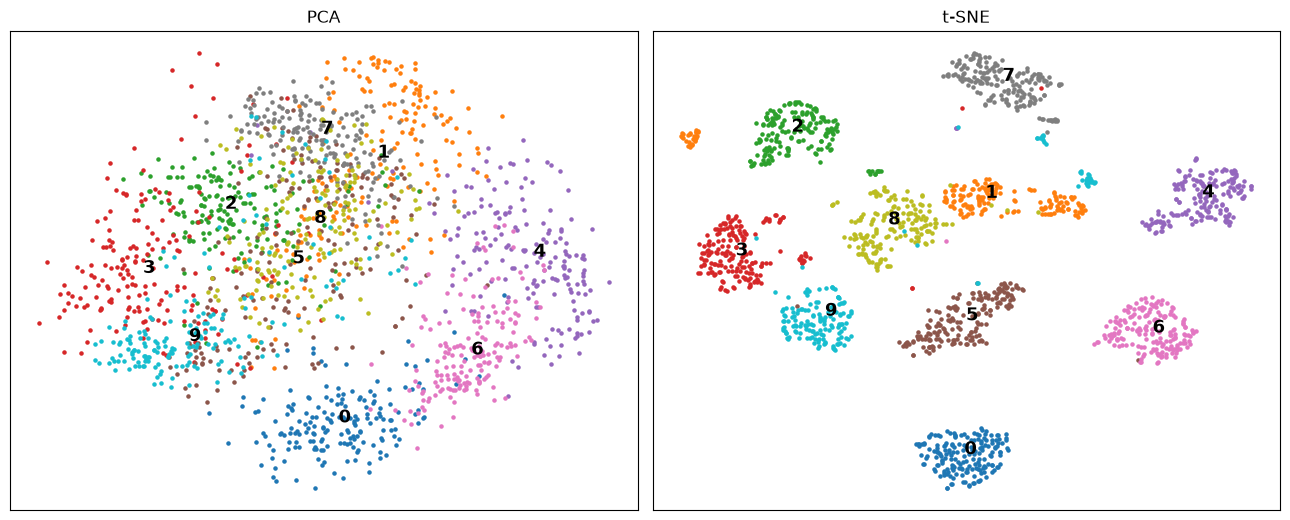

In [3]:
Z_pca = PCA(2).fit_transform(X)
Z_tsne = TSNE(2, perplexity=30, init="pca", random_state=0).fit_transform(X)
Z_pca50 = PCA(50).fit_transform(X)
Z_tsne_pca = TSNE(2, perplexity=30, init="pca", random_state=0).fit_transform(Z_pca50)

for nome, Z in [("PCA 2D", Z_pca), ("t-SNE", Z_tsne), ("PCA 50 -> t-SNE", Z_tsne_pca)]:
    print(f"{nome:>16s}: trustworthiness (10 vizinhos) = {trustworthiness(X, Z, n_neighbors=10):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))
for ax, Z, tit in [(axes[0], Z_pca, "PCA"), (axes[1], Z_tsne, "t-SNE")]:
    for d in range(10):
        ax.scatter(*Z[y == d].T, s=5, color=CMAP10(d))
        ax.annotate(str(d), np.median(Z[y == d], axis=0), fontsize=13, fontweight="bold")
    ax.set_title(tit); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 3. Armadilha 1: tamanhos e distâncias entre grupos

Dois grupos com 200 pontos cada: um com desvio-padrão 0,3, outro com
desvio-padrão 3 (dez vezes mais espalhado).

In [4]:
A = rng.normal(0, 0.3, (200, 10))
B = rng.normal(0, 3.0, (200, 10)) + 15
D = np.vstack([A, B])
Z = TSNE(2, perplexity=30, init="pca", random_state=0).fit_transform(D)
for nome, sl in [("A (compacto)", slice(0, 200)), ("B (10x mais espalhado)", slice(200, 400))]:
    orig = np.sqrt(((D[sl] - D[sl].mean(axis=0)) ** 2).sum(axis=1)).mean()
    mapa = np.sqrt(((Z[sl] - Z[sl].mean(axis=0)) ** 2).sum(axis=1)).mean()
    print(f"{nome:>24s}: raio médio no original = {orig:6.2f} | no t-SNE = {mapa:6.2f}")

            A (compacto): raio médio no original =   0.94 | no t-SNE =   6.25
  B (10x mais espalhado): raio médio no original =   9.35 | no t-SNE =   6.25


No original, B é dez vezes mais espalhado que A. No mapa, os raios ficam
da mesma ordem: o t-SNE ajusta $\sigma_i$ à densidade local e "normaliza"
os tamanhos.

## 4. Armadilha 2: ilhas em dados sem estrutura

500 pontos de uma única gaussiana em 20 dimensões — não há grupos. Com
perplexidade baixa, o t-SNE desenha ilhas mesmo assim.

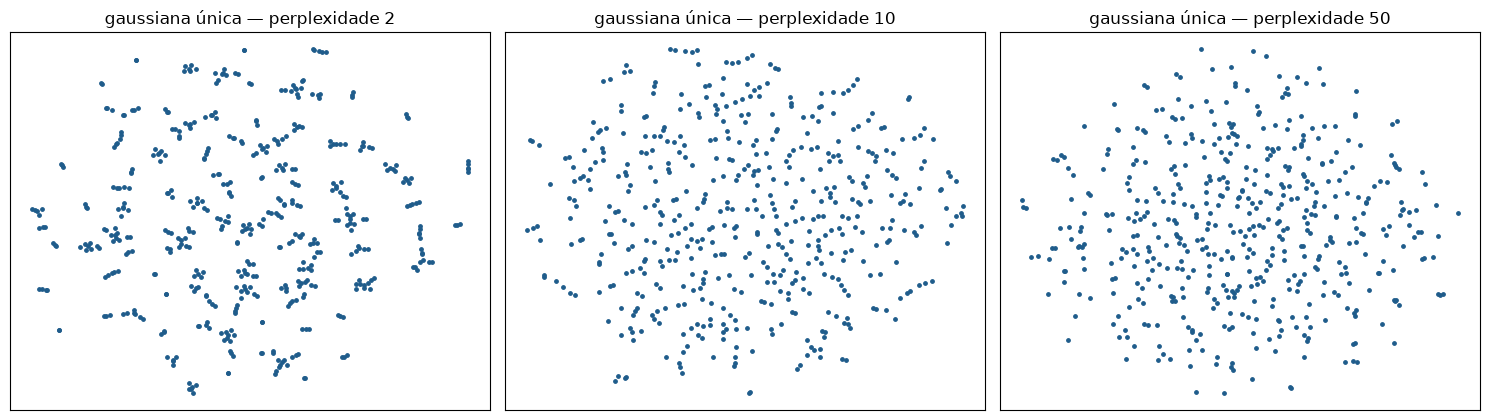

In [5]:
sem_estrutura = rng.normal(size=(500, 20))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, perp in zip(axes, [2, 10, 50]):
    Zs = TSNE(2, perplexity=perp, init="random", random_state=0).fit_transform(sem_estrutura)
    ax.scatter(Zs[:, 0], Zs[:, 1], s=6, color=AZUL)
    ax.set_title(f"gaussiana única — perplexidade {perp}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 5. Armadilha 3: a semente muda o desenho

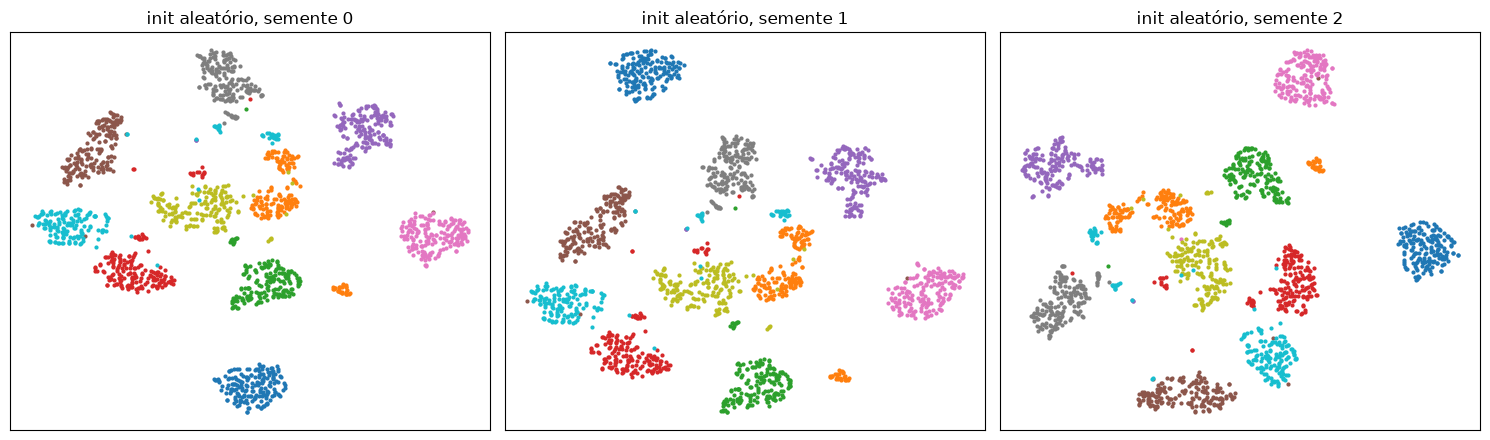

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, semente in zip(axes, [0, 1, 2]):
    Zs = TSNE(2, perplexity=30, init="random", random_state=semente).fit_transform(Z_pca50)
    for d in range(10):
        ax.scatter(*Zs[y == d].T, s=4, color=CMAP10(d))
    ax.set_title(f"init aleatório, semente {semente}"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

A **vizinhança** de cada dígito é preservada nas três execuções, mas a
posição relativa dos grupos muda. `init="pca"` (padrão nas versões
recentes do `scikit-learn`) torna o resultado mais estável e preserva um
pouco mais da estrutura global.

## 6. Rolo suíço: PCA, Isomap, LLE e t-SNE

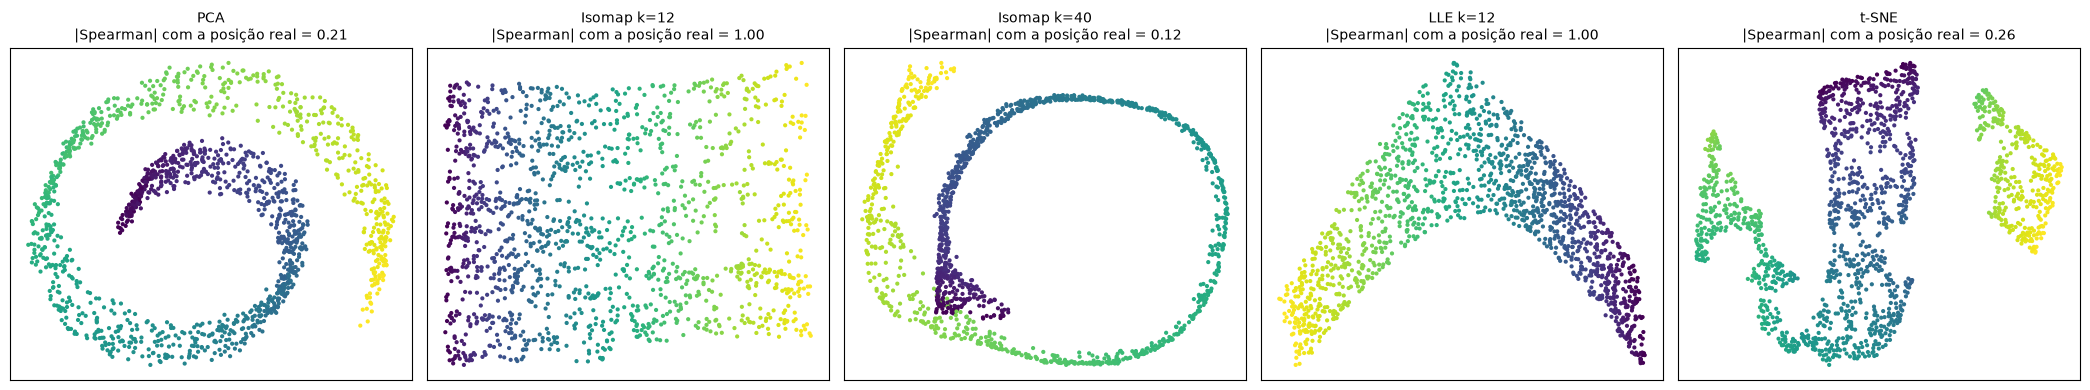

In [7]:
R, t = make_swiss_roll(n_samples=1500, noise=0.2, random_state=0)
metodos = {"PCA": PCA(2), "Isomap k=12": Isomap(n_neighbors=12, n_components=2),
           "Isomap k=40": Isomap(n_neighbors=40, n_components=2),
           "LLE k=12": LocallyLinearEmbedding(n_neighbors=12, n_components=2, random_state=0),
           "t-SNE": TSNE(2, perplexity=50, init="pca", random_state=0)}
fig, axes = plt.subplots(1, 5, figsize=(21, 4))
for ax, (nome, m) in zip(axes, metodos.items()):
    Zr = m.fit_transform(R)
    # correlação de Spearman entre a posição real na folha (t) e a melhor coordenada do mapa
    rho = max(abs(pd.Series(Zr[:, j]).corr(pd.Series(t), method="spearman")) for j in range(2))
    ax.scatter(Zr[:, 0], Zr[:, 1], c=t, cmap="viridis", s=4)
    ax.set_title(f"{nome}\n|Spearman| com a posição real = {rho:.2f}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

**Leitura esperada:** Isomap com $k$ pequeno desenrola a folha (a
coordenada do mapa acompanha a posição real, Spearman alto); com $k$
grande, o grafo cria "atalhos" entre voltas e o resultado degrada. PCA
achata tudo. t-SNE preserva vizinhanças locais, mas pode rasgar a folha.

## 7. Autoencoder vs. PCA

Um autoencoder pequeno (64 → 32 → k → 32 → 64) treinado com o
`MLPRegressor` para reconstruir os dígitos, comparado ao PCA com o mesmo
número de dimensões no gargalo. E um autoencoder **linear**
(`activation="identity"`), que deveria empatar com o PCA.

In [8]:
Xs = MinMaxScaler().fit_transform(X)
X_tr, X_te = Xs[:1400], Xs[1400:]
linhas = []
for k in [2, 5, 10]:
    p = PCA(k).fit(X_tr)
    eqm_pca = np.mean((X_te - p.inverse_transform(p.transform(X_te))) ** 2)
    ae_lin = MLPRegressor(hidden_layer_sizes=(k,), activation="identity", max_iter=3000,
                          learning_rate_init=0.005, random_state=0).fit(X_tr, X_tr)
    ae = MLPRegressor(hidden_layer_sizes=(32, k, 32), activation="relu", max_iter=3000,
                      learning_rate_init=0.002, random_state=0).fit(X_tr, X_tr)
    linhas.append({"k": k, "PCA": eqm_pca,
                   "autoencoder linear": np.mean((X_te - ae_lin.predict(X_te)) ** 2),
                   "autoencoder não linear": np.mean((X_te - ae.predict(X_te)) ** 2)})
print("erro quadrático médio de reconstrução no conjunto de teste:")
print(pd.DataFrame(linhas).set_index("k").round(4).to_string())

erro quadrático médio de reconstrução no conjunto de teste:
       PCA  autoencoder linear  autoencoder não linear
k                                                     
2   0.0531              0.0623                  0.0601
5   0.0355              0.0382                  0.0509
10  0.0210              0.0258                  0.0273


**Leitura esperada:** o autoencoder linear fica perto do PCA, mas um
pouco pior. Pelo resultado de Baldi & Hornik citado no `teoria.pdf`, o
ótimo de um autoencoder linear **é** o subespaço do PCA — mas o PCA chega
a esse ótimo em forma fechada (SVD), enquanto o autoencoder se aproxima
dele por gradiente descendente e para antes. O autoencoder não linear,
aqui, também não vence: com 1.400 imagens de 64 pixels não há dados
suficientes para a flexibilidade extra pagar o custo. Essa é a situação
típica em dados tabulares de tamanho moderado — autoencoders brilham com
muitos dados e estrutura fortemente não linear (imagens grandes, áudio,
texto), que é o território do tema 8.

## O que levar deste notebook

- Perplexidade é o número efetivo de vizinhos; ela define $\sigma_i$ ponto
  a ponto.
- Use trustworthiness para comparar mapas: ela mede o que t-SNE promete.
- Tamanhos, distâncias entre grupos e ilhas de um t-SNE não são evidência;
  varie perplexidade e semente antes de concluir qualquer coisa.
- Isomap desenrola manifolds limpos, mas depende do número de vizinhos.
- Autoencoder linear ≈ PCA; a não linearidade tem custo e nem sempre paga.

→ Próximo: **Exercícios** do módulo; depois, o módulo 3, **Detecção de
Anomalias**.